In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
2methylpropane,58.12,2.265875,3.511999942,216.5313375,0,0
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,2methylpropane,-0.01
"""

model = PCSAFT(["co2", "2methylpropane"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 193.60201712236508; 193.60201712236508 216.5313375]
[2.785e-10 3.148499971e-10; 3.148499971e-10 3.5119999420000004e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 280 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 280 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 800.0,
        :guess   => 193.6
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 800.0, :param => :epsilon, :indices => (1, 2), :guess => 193.6, :lower => 10.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_2methylpropane.csv")
fix_line_endings("vley_2methylpropane.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_2methylpropane.csv"
        "vley_2methylpropane.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_2methylpropane.csv
Fixed: vley_2methylpropane.csv
Initial objective value: 0.15490861748629398


In [6]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([173.31540280405048], PCSAFT{BasicIdeal, Float64}("co2", "2methylpropane"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 173.31540280405048; 173.31540280405048 216.5313375]
[2.785e-10 3.148499971e-10; 3.148499971e-10 3.5119999420000004e-10]
kij = 0.09583299061676342


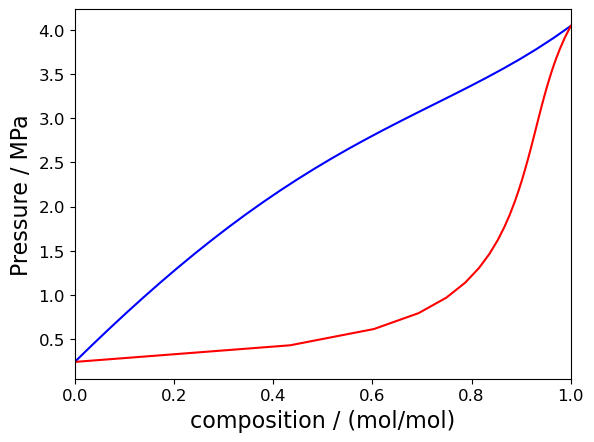

([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5], PyCall.PyObject[PyObject Text(0, 0.0, '0.0'), PyObject Text(0, 0.5, '0.5'), PyObject Text(0, 1.0, '1.0'), PyObject Text(0, 1.5, '1.5'), PyObject Text(0, 2.0, '2.0'), PyObject Text(0, 2.5, '2.5'), PyObject Text(0, 3.0, '3.0'), PyObject Text(0, 3.5, '3.5'), PyObject Text(0, 4.0, '4.0'), PyObject Text(0, 4.5, '4.5')])

In [8]:
import PyPlot; const plt = PyPlot

N    = 30
T    = 280

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [9]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [12]:
aard_p   = calculate_AAD(model_opt, "vlep_2methylpropane.csv", vle_p)


=== AAD: vlep_2methylpropane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.9325      3886500.000000  3788318.890296  2.5262  
0.8878      3736100.000000  3637321.403688  2.6439  
0.8436      3553600.000000  3499213.131867  1.5305  
0.6381      2946600.000000  2912953.106255  1.1419  
0.5227      2549100.000000  2560063.082196  0.4301  
0.3894      2067800.000000  2087294.112030  0.9427  
0.2630      1559600.000000  1561552.373972  0.1252  
0.1700      1118800.000000  1126806.144581  0.7156  
0.1274      906000.000000  915062.138115  1.0002  
0.0889      703400.000000  717388.244226  1.9887  
AARD = 1.3045%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


1.3044971828405747

In [14]:
aard_p   = calculate_AAD(model_opt, "vley_2methylpropane.csv", vle_y)


=== AAD: vley_2methylpropane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.9325      0.977300      0.978312      0.1036  
0.8878      0.969900      0.968033      0.1925  
0.8436      0.959200      0.959754      0.0577  
0.6381      0.933800      0.931068      0.2926  
0.5227      0.916500      0.914827      0.1825  
0.3894      0.894700      0.889163      0.6189  
0.2630      0.858600      0.846882      1.3647  
0.1700      0.805800      0.785023      2.5785  
0.1274      0.755500      0.734475      2.7830  
0.0889      0.695300      0.660988      4.9349  
AARD = 1.3109%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


1.3108893324322402